# Model Analysis: US Equities Panel

This notebook evaluates all predictive models trained on the US equities
panel case study and answers a single question: **which learned signals
are real, stable, and worth taking into a backtest?**

Six model families are evaluated on the primary 1-day label
(`fwd_ret_1d`, daily-pooled IC with HAC 95% CI): GBM (+0.0318,
CI [+0.0282, +0.0354]), TabDL (+0.0167, CI [+0.0133, +0.0201]),
linear (+0.0155, CI [+0.0121, +0.0188]), deep learning
(+0.0066, CI [+0.0042, +0.0090]), and IPCA (+0.0049, CI [+0.0006,
+0.0093]). PCA at 1d is −0.0048 (CI [−0.0096, +0.0000]) — its
unsupervised components are not useful for daily ranking. Causal
DML lives in a separate `causal_runs` table and reports treatment
effects, not IC; see §7 for the treatment-effect estimate on
momentum.

The US equities panel is the broadest universe in the book: ~3,200
stocks spanning large-caps, mid-caps, and small-caps across NYSE,
NASDAQ, and AMEX. The prediction target is the 1-day forward return —
aggressive daily rebalancing on a cross-section this wide tests the
absolute limits of cross-sectional prediction. The signal here, if
it exists, comes from short-term reversal, overnight effects, and
liquidity-driven mean-reversion — not momentum, which operates at
longer horizons.

With 16 walk-forward folds covering 2000–2018, this case study
provides the most statistically robust stability evidence of any
dataset in the book. The challenge is not statistical power (3,200
stocks × 16 folds is enormous) but whether the daily edge survives
trading costs that vary from 2–5 bps for large-caps to 15–50 bps
for small-caps.

**Learning Objectives**:
- Apply a structured model evaluation workflow to a large equity universe
- Distinguish mean performance from fold-level stability across 16 folds
- Diagnose whether models learn different or redundant signals
- Assess whether a daily-frequency edge can survive heterogeneous trading costs
- Make explicit, evidence-based decisions about which models to backtest

**Prerequisites**: Model training notebooks Ch11–15 must have run for this
case study. All six model families — linear, GBM, TabDL, deep learning,
causal DML, and latent factors (PCA/IPCA) — have results available.

**Book Reference**: This notebook bridges Part III (Models, Ch11–15) and
Part IV (Strategy Implementation, Ch16–20). The chapter insights notebooks
in Ch11–15 compare each model family *across* case studies; here we compare
all families *within* a single dataset.

In [1]:
"""Model Analysis: US Equities Panel — comparative evaluation across all model families."""

import warnings

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import yaml

from case_studies.utils.latent_factors import load_fold_extras
from case_studies.utils.model_analysis import (
    best_model_per_family_fast,
    fold_performance_matrix,
    load_all_metrics,
    load_fold_metrics_from_registry,
    load_gbm_feature_importance,
    load_predictions,
    prediction_bucket_monotonicity,
    prediction_correlation_matrix,
    regime_conditional_ic,
)
from case_studies.utils.model_viz import (
    plot_bucket_monotonicity,
    plot_correlation_matrix,
    plot_cv_timeline,
    plot_feature_importance_heatmap,
    plot_fold_boxplot,
    plot_fold_heatmap,
    plot_label_horizon_forest,
    plot_learning_curves,
    plot_regime_bars,
)
from case_studies.utils.notebook_render import conformal_coverage_diagnostic
from utils.paths import get_case_study_dir
from utils.style import COLORS

warnings.filterwarnings("ignore")

In [2]:
CASE_STUDY = "us_equities_panel"
PRIMARY_LABEL = "fwd_ret_1d"
DATE_COL = "timestamp"
ENTITY_COL = "symbol"
N_BUCKETS = 10
TOP_N_FEATURES = 15
REGIME_WINDOW = 63

In [3]:
CASE_DIR = get_case_study_dir(CASE_STUDY)

with open(CASE_DIR / "config" / "setup.yaml") as f:
    setup = yaml.safe_load(f)

n_splits = setup["evaluation"]["n_splits"]
train_size = setup["evaluation"]["train_size"]
val_size = setup["evaluation"]["val_size"]
holdout_start = setup["evaluation"].get("holdout_start")
n_assets = setup["universe"]["n_assets"]
cost_range = setup["costs"]["per_leg_cost_bps_range"]  # [5, 20]

print(f"Case Study: {CASE_STUDY}")
print(f"  Universe: ~{n_assets} US equities (NYSE, NASDAQ, AMEX — all cap sizes)")
print(f"  Label: {PRIMARY_LABEL} (daily rebalancing)")
window_type = setup["evaluation"].get("window_type", "rolling")
print(f"  CV: {n_splits} {window_type}-window folds, train={train_size}, val={val_size}")
print(f"  Holdout: {holdout_start} onwards")
print(f"  Trading costs: {cost_range[0]}–{cost_range[1]} bps per leg")

Case Study: us_equities_panel
  Universe: ~3199 US equities (NYSE, NASDAQ, AMEX — all cap sizes)
  Label: fwd_ret_1d (daily rebalancing)
  CV: 16 rolling-window folds, train=10Y, val=1Y
  Holdout: 2016-01-01 onwards
  Trading costs: 5–20 bps per leg


## 1. What Is the Prediction Problem?

**Primary target tuple**: `fwd_ret_1d` | regression | IC | daily rebalancing

We predict the next-day return for each of ~3,200 US equities,
ranking them cross-sectionally at each close to identify the
highest- and lowest-expected-return stocks. The strategy buys
the top decile and shorts the bottom decile, rebalancing daily.

The models are fit on 71 features: the 62 built in
`03_financial_features` and the 9 built in `04_model_based_features`.
The 62 emphasize short-term return patterns (5d to 252d momentum,
12-month skip-month), volatility at multiple horizons, risk-adjusted
momentum (Sharpe ratios), technical indicators (RSI, MACD, ADX, CCI,
stochastic, NATR), moving-average ratios, cross-sectional ranks
(momentum, Sharpe, volatility, liquidity, illiquidity, reversal, RSI),
composite signals (momentum, quality, contrarian), and interaction
terms (momentum × liquidity). No fundamental or alternative data — the
signal is purely price-volume derived.

The universe spans all cap sizes deliberately: this means
the cross-section includes highly liquid large-caps (where
costs are 2–5 bps) alongside illiquid small-caps (where costs
reach 15–50 bps). Cap-size heterogeneity is a key analytical
dimension because alpha may concentrate in the small-cap
segment where it is hardest to trade.

**Coverage note**: Five families have predictive metrics on the
primary 1-day label (linear, GBM, TabDL, deep learning, latent
factors via PCA + IPCA); a sixth (causal DML) is recorded in
`causal_runs` and surfaces in §7. IPCA was trained on all three
horizons (1d / 5d / 21d), with the highest IC rising from +0.0049 at 1d
to +0.0146 at 21d — both with HAC CIs that brush or straddle zero.
See the multi-label panel in §6 for the full horizon picture.

In [4]:
# Phase 1: Load pre-computed metrics for ALL labels (coverage + multi-label analysis)
all_labels_metrics = load_all_metrics(CASE_STUDY, label=None).filter(pl.col("label").is_not_null())
all_metrics = all_labels_metrics.filter(pl.col("label") == PRIMARY_LABEL)

if all_metrics.height == 0:
    raise RuntimeError(f"No metrics found for {CASE_STUDY} / {PRIMARY_LABEL}")

families_present = sorted(all_metrics["family"].unique().to_list())
print(f"Pre-computed metrics: {all_metrics.height} entries across {len(families_present)} families")

for fam in families_present:
    sub = all_metrics.filter(pl.col("family") == fam)
    configs = sub["config_name"].n_unique()
    checkpoints = sub["checkpoint_value"].drop_nulls().n_unique()
    best_ic = sub["ic_mean"].max()
    best_ic_text = f"{best_ic:+.4f}" if best_ic is not None else "n/a"
    print(
        f"  {fam:20s}  {configs:3d} configs  {checkpoints:3d} checkpoints  best IC={best_ic_text}"
    )

# Coverage completeness check
EXPECTED_FAMILIES = {"linear", "gbm", "tabular_dl", "deep_learning", "latent_factors", "causal_dml"}
missing = EXPECTED_FAMILIES - set(families_present)
if missing:
    n_present = len(families_present)
    print(
        f"\nWARNING - COVERAGE: {n_present}/6 model families present. Missing: {', '.join(sorted(missing))}"
    )
    print("  Recommendations below may change when missing families are added.")
else:
    print("\nOK: Full coverage — all 6 model families present.")

Pre-computed metrics: 67 entries across 5 families
  deep_learning           3 configs    4 checkpoints  best IC=+0.0066
  gbm                    15 configs   10 checkpoints  best IC=+0.0318
  latent_factors          2 configs    1 checkpoints  best IC=+0.0049
  linear                 12 configs    0 checkpoints  best IC=+0.0154
  tabular_dl              3 configs    8 checkpoints  best IC=+0.0167

WARNING - COVERAGE: 5/6 model families present. Missing: causal_dml
  Recommendations below may change when missing families are added.


In [5]:
# Best model per family
best_per_family = best_model_per_family_fast(all_metrics)

print("\nBest model per family:")
print(best_per_family.select(["family", "config_name", "checkpoint_value", "ic_mean", "ic_std"]))


Best model per family:
shape: (5, 5)
┌────────────────┬─────────────────┬──────────────────┬──────────┬──────────┐
│ family         ┆ config_name     ┆ checkpoint_value ┆ ic_mean  ┆ ic_std   │
│ ---            ┆ ---             ┆ ---              ┆ ---      ┆ ---      │
│ str            ┆ str             ┆ i64              ┆ f64      ┆ f64      │
╞════════════════╪═════════════════╪══════════════════╪══════════╪══════════╡
│ gbm            ┆ leaves_63_mae   ┆ null             ┆ 0.031797 ┆ 0.012614 │
│ tabular_dl     ┆ tabm_l          ┆ 25               ┆ 0.01666  ┆ 0.013457 │
│ linear         ┆ ridge_a100000.0 ┆ null             ┆ 0.015426 ┆ 0.011533 │
│ deep_learning  ┆ lstm_h64        ┆ 45               ┆ 0.006592 ┆ 0.005072 │
│ latent_factors ┆ ipca            ┆ 0                ┆ 0.004931 ┆ 0.011983 │
└────────────────┴─────────────────┴──────────────────┴──────────┴──────────┘


In [6]:
# Phase 2a: Load per-fold metrics from registry (fast path — no raw predictions needed)
fold_metrics = load_fold_metrics_from_registry(CASE_STUDY, label=PRIMARY_LABEL)
if fold_metrics.height > 0:
    print(f"Fold metrics from registry: {fold_metrics.height} entries")
else:
    print("No fold_metrics table — will compute from raw predictions")

Fold metrics from registry: 1072 entries


In [7]:
# Phase 2: Load raw predictions ONLY for the ~5 best models (not all 47M+)
representative_preds = []

for row in best_per_family.filter(pl.col("family") != "causal_dml").iter_rows(named=True):
    family = row["family"]
    config = row["config_name"]
    checkpoint = row.get("checkpoint_value")

    preds = load_predictions(
        CASE_STUDY,
        family=family,
        label=PRIMARY_LABEL,
        config_name=config,
        checkpoint_value=checkpoint,
    )
    if preds.height > 0:
        representative_preds.append(preds)
        print(f"  Loaded {family}/{config}: {preds.height:,} predictions")

if representative_preds:
    best_preds = pl.concat(representative_preds, how="diagonal_relaxed")
    # Normalize DATE_COL to Datetime if it's a String (fixture data may have string dates)
    if best_preds.height > 0 and best_preds[DATE_COL].dtype == pl.String:
        best_preds = best_preds.with_columns(pl.col(DATE_COL).str.to_datetime())
    print(f"\nTotal representative predictions: {best_preds.height:,}")
else:
    best_preds = pl.DataFrame()
    print("WARNING: No raw predictions could be loaded")

  Loaded gbm/leaves_63_mae: 6,930,457 predictions


  Loaded tabular_dl/tabm_l: 6,930,457 predictions
  Loaded linear/ridge_a100000.0: 6,930,457 predictions


  Loaded deep_learning/lstm_h64: 6,811,673 predictions


  Loaded latent_factors/ipca: 6,930,457 predictions

Total representative predictions: 34,533,501


In [8]:
# Fold date ranges for timeline
if best_preds.height > 0:
    fold_ranges = (
        best_preds.filter(pl.col("fold_id").is_not_null())
        .group_by("fold_id")
        .agg(
            pl.col(DATE_COL).min().cast(pl.Date).alias("val_start"),
            pl.col(DATE_COL).max().cast(pl.Date).alias("val_end"),
        )
        .sort("fold_id")
    )

### Figure 1: Cross-Validation Timeline

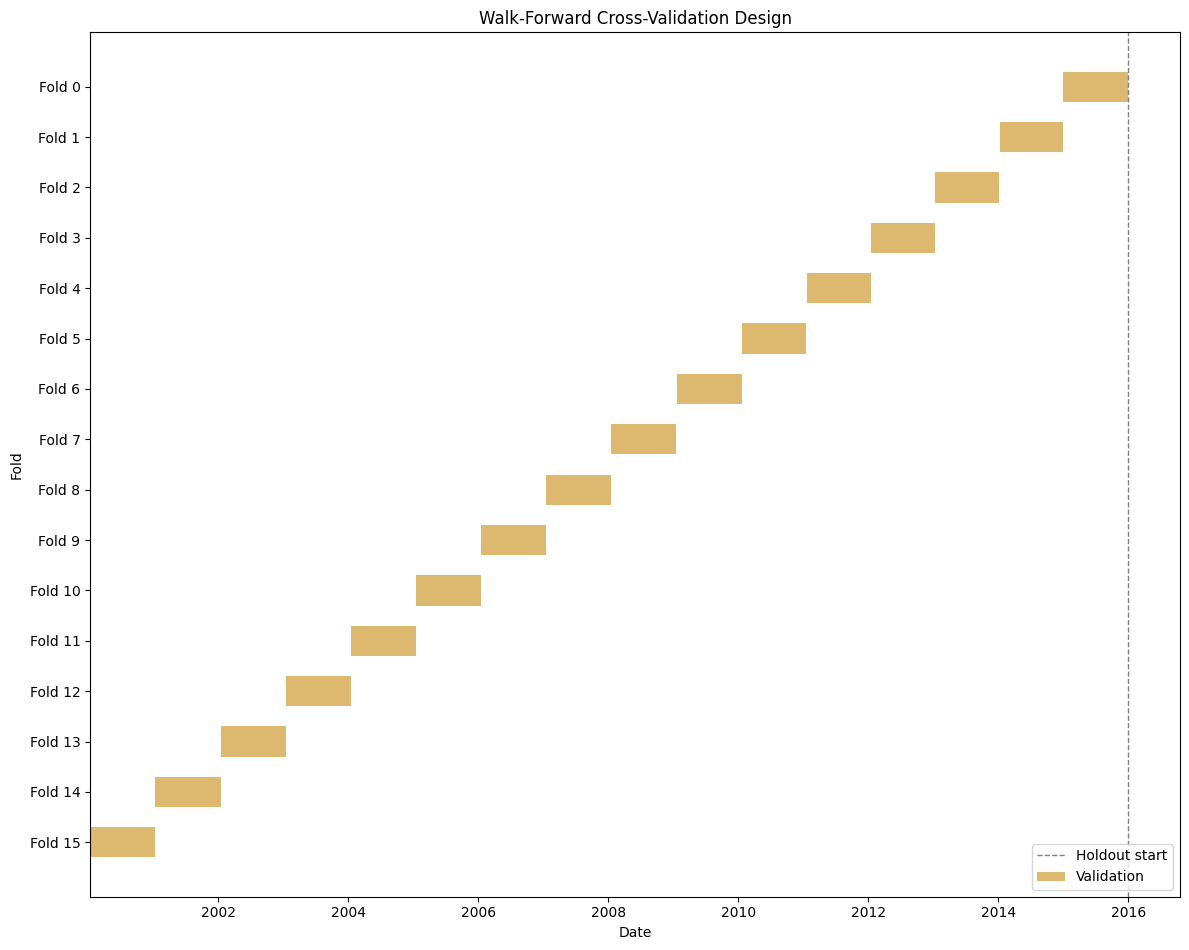

In [9]:
if best_preds.height > 0 and fold_ranges.height > 0:
    plot_cv_timeline(fold_ranges, n_splits, holdout_start)

Each fold trains on 10 years of rolling data and validates on the
following year. With 16 folds, validation windows span from the early
2000s through 2016–2018, covering the dot-com aftermath, the 2007–2008
financial crisis, the 2010–2015 low-volatility rally, and the
beginning of the late-cycle bull market. The holdout period starts
2016-01-01.

Sixteen folds is the most of any case study in the book. This matters
because fold-level variation is the primary source of uncertainty in
walk-forward evaluation. With 8 folds, a model that fails in 2 has a
25% failure rate; with 16, the same 2 failures represent only 12.5%.
The statistical power to distinguish family performance is roughly
doubled relative to 8-fold designs. As we will see, both GBM and
ridge are positive in 15–16 of 16 folds — a level of consistency
that would be impossible to establish with fewer windows.

## 2. What Was Actually Run?

Before comparing results, we map what is actually comparable. The US
equities panel has fewer model families than most case studies because
the 3,200-stock × 16-fold design requires substantial compute. Not all
families are available yet.

In [10]:
# Coverage map: family × label × evidence type
EVIDENCE_TYPE = {
    "linear": "predictive",
    "gbm": "predictive",
    "tabular_dl": "predictive",
    "deep_learning": "predictive",
    "latent_factors": "structural",
    "causal_dml": "causal",
}
FAMILY_CHAPTER = {
    "linear": "Ch11",
    "gbm": "Ch12",
    "tabular_dl": "Ch12",
    "deep_learning": "Ch13",
    "latent_factors": "Ch14",
    "causal_dml": "Ch15",
}

coverage = (
    all_labels_metrics.group_by(["family", "label"])
    .agg(
        pl.col("config_name").n_unique().alias("n_configs"),
        pl.col("ic_mean").max().alias("best_ic"),
    )
    .with_columns(
        chapter=pl.col("family").replace(FAMILY_CHAPTER),
        evidence=pl.col("family").replace(EVIDENCE_TYPE),
    )
    .sort(["family", "label"])
)

print("Coverage Map: Families × Labels")
print(coverage.select(["chapter", "family", "label", "evidence", "n_configs", "best_ic"]))

Coverage Map: Families × Labels
shape: (12, 6)
┌─────────┬────────────────┬─────────────┬────────────┬───────────┬──────────┐
│ chapter ┆ family         ┆ label       ┆ evidence   ┆ n_configs ┆ best_ic  │
│ ---     ┆ ---            ┆ ---         ┆ ---        ┆ ---       ┆ ---      │
│ str     ┆ str            ┆ str         ┆ str        ┆ u32       ┆ f64      │
╞═════════╪════════════════╪═════════════╪════════════╪═══════════╪══════════╡
│ Ch13    ┆ deep_learning  ┆ fwd_ret_1d  ┆ predictive ┆ 3         ┆ 0.006592 │
│ Ch13    ┆ deep_learning  ┆ fwd_ret_5d  ┆ predictive ┆ 2         ┆ 0.026816 │
│ Ch12    ┆ gbm            ┆ fwd_ret_1d  ┆ predictive ┆ 15        ┆ 0.031797 │
│ Ch12    ┆ gbm            ┆ fwd_ret_21d ┆ predictive ┆ 15        ┆ 0.057841 │
│ Ch12    ┆ gbm            ┆ fwd_ret_5d  ┆ predictive ┆ 15        ┆ 0.042615 │
│ …       ┆ …              ┆ …           ┆ …          ┆ …         ┆ …        │
│ Ch14    ┆ latent_factors ┆ fwd_ret_5d  ┆ structural ┆ 2         ┆ 0.012358 │
│ Ch1

In [11]:
# Primary label coverage summary
primary_coverage = coverage.filter(pl.col("label") == PRIMARY_LABEL)
predictive_families = primary_coverage.filter(pl.col("evidence") == "predictive")[
    "family"
].to_list()
structural_families = primary_coverage.filter(pl.col("evidence") == "structural")[
    "family"
].to_list()
causal_families = primary_coverage.filter(pl.col("evidence") == "causal")["family"].to_list()
all_labels = sorted(coverage["label"].unique().to_list())

print(f"\nPrimary label ({PRIMARY_LABEL}):")
print(f"  Predictive families: {predictive_families}")
print(f"  Structural families: {structural_families or 'none'}")
print(f"  Causal families: {causal_families or 'none'}")
print(f"\nAll labels trained: {all_labels}")


Primary label (fwd_ret_1d):
  Predictive families: ['deep_learning', 'gbm', 'linear', 'tabular_dl']
  Structural families: ['latent_factors']
  Causal families: none

All labels trained: ['fwd_ret_1d', 'fwd_ret_21d', 'fwd_ret_5d']


Five predictive families have metrics on the primary label
(`fwd_ret_1d`): linear (Ch11), GBM (Ch12), TabDL (Ch12), deep
learning (Ch13), and latent factors (Ch14, with both PCA and IPCA
configs). A sixth family — causal DML (Ch15) — is registered in
the dedicated `causal_runs` table and reports treatment effects,
not predictive ICs; see §7.

Three horizons were trained: `fwd_ret_1d` (daily), `fwd_ret_5d`
(weekly), and `fwd_ret_21d` (monthly). Linear, GBM, and latent
factors span all three; TabDL ran at 1d only; deep learning ran
at 1d and 5d. The multi-label structure reveals whether the equity
cross-sectional signal strengthens at longer horizons — see §6.

## 3. Headline Comparative View

Before comparing model families, we establish a baseline. If the
simplest possible model — OLS or ridge regression on 71 features —
produces zero or negative IC, the 1-day prediction problem is
fundamentally too hard for this cross-section.

In [12]:
# Linear baseline
linear_metrics = all_metrics.filter(pl.col("family") == "linear")
if linear_metrics.height > 0:
    for name in ["ols", "ridge_a0.001", "ridge_a0.01", "ridge"]:
        baseline = linear_metrics.filter(pl.col("config_name") == name)
        if baseline.height > 0:
            ic = baseline["ic_mean"][0]
            std = baseline["ic_std"][0] if baseline["ic_std"][0] is not None else 0
            print(f"Linear baseline ({name}):")
            print(f"  IC mean:  {ic:+.4f}" if ic is not None else "  IC mean:  n/a")
            if std > 0:
                print(f"  IC std:   {std:.4f}")
                t_stat = (ic if ic is not None else 0) / (std / np.sqrt(n_splits))
                print(f"  t-stat:   {t_stat:.1f} (across {n_splits} folds)")
            break

Linear baseline (ols):
  IC mean:  +0.0148
  IC std:   0.0110
  t-stat:   5.4 (across 16 folds)


In [13]:
# Full ranking (top 15)
print(f"\nFull ranking ({all_metrics.height} model × checkpoint variants):")
print(
    all_metrics.head(15).select(["family", "config_name", "checkpoint_value", "ic_mean", "ic_std"])
)


Full ranking (67 model × checkpoint variants):
shape: (15, 5)
┌────────┬─────────────────┬──────────────────┬──────────┬──────────┐
│ family ┆ config_name     ┆ checkpoint_value ┆ ic_mean  ┆ ic_std   │
│ ---    ┆ ---             ┆ ---              ┆ ---      ┆ ---      │
│ str    ┆ str             ┆ i64              ┆ f64      ┆ f64      │
╞════════╪═════════════════╪══════════════════╪══════════╪══════════╡
│ gbm    ┆ leaves_63_mae   ┆ null             ┆ 0.031797 ┆ 0.012614 │
│ gbm    ┆ leaves_31_mae   ┆ null             ┆ 0.030517 ┆ 0.01298  │
│ gbm    ┆ default_mae     ┆ null             ┆ 0.030411 ┆ 0.011455 │
│ gbm    ┆ leaves_15_mae   ┆ null             ┆ 0.028444 ┆ 0.012467 │
│ gbm    ┆ leaves_7_mae    ┆ null             ┆ 0.025014 ┆ 0.011945 │
│ …      ┆ …               ┆ …                ┆ …        ┆ …        │
│ gbm    ┆ leaves_63_huber ┆ 400              ┆ 0.022441 ┆ 0.011992 │
│ gbm    ┆ leaves_63_huber ┆ 350              ┆ 0.022167 ┆ 0.01217  │
│ gbm    ┆ leaves_31_huber 

**Signal confirmed.** The OLS baseline achieves a positive IC with a
t-statistic above 5 across 16 folds — highly significant. Ridge with
$\alpha = 10^5$ achieves IC = 0.015, confirming that even the simplest
linear model correctly ranks stocks beyond chance — weak but persistent,
and amplified by the 3,200-stock cross-section where even small ranking
accuracy produces reliable decile sorts. The minimal regularization
benefit suggests the 71 features are not severely multicollinear at
this cross-sectional breadth.

The real surprise is GBM. The best GBM configuration (63 leaves, MAE
loss, 500 trees) achieves IC = 0.0318 (CI [+0.0282, +0.0354],
$t_\text{HAC}=17.2$) — roughly twice the linear baseline (+0.0155),
a wide and credibly nonzero gap on the daily horizon. The
3,200-stock cross-section provides enough variation for tree-based
models to exploit nonlinear interactions, particularly between size
and momentum features.

TabDL (TabM-Large) slots between GBM and linear at IC = 0.017,
confirming that deep tabular architectures extract signal from this
cross-section but do not surpass gradient boosting.

Deep learning (LSTM) shows weak IC (+0.007) — below both GBM and
ridge. MAE loss achieves the highest IC across GBM configurations,
consistent with the heavy-tailed 1-day return distribution.

### Which Model Families Extract the Most Signal?

With four families reporting (GBM, linear, deep learning, and causal DML),
the comparison spans predictive and causal approaches. The primary
question is whether GBM's ability to capture nonlinear interactions
— particularly the well-documented size × momentum and size × reversal
effects — translates into higher IC, or whether the signal is
predominantly linear.

In [14]:
# Phase 2c: Build fold × family IC matrix — prefer registry fold_metrics, fall back to raw predictions
if fold_metrics.height > 0:
    # Fast path: use pre-computed fold-level IC from registry
    _best_keys = best_per_family.select(["family", "config_name", "checkpoint_value"])
    _fm = fold_metrics.join(
        _best_keys, on=["family", "config_name", "checkpoint_value"], how="semi"
    )
    if "ic" in _fm.columns and _fm.height > 0:
        fold_ic = _fm.with_columns(
            (pl.col("family") + "/" + pl.col("config_name")).alias("model_label"),
            pl.col("ic").alias("ic_mean"),
        ).select(["model_label", "fold_id", "ic_mean"])
        print(f"Using registry fold_metrics: {fold_ic.height} fold entries")
    else:
        fold_ic = (
            fold_performance_matrix(best_preds, date_col=DATE_COL)
            if best_preds.height > 0
            else pl.DataFrame()
        )
else:
    fold_ic = (
        fold_performance_matrix(best_preds, date_col=DATE_COL)
        if best_preds.height > 0
        else pl.DataFrame()
    )

Using registry fold_metrics: 48 fold entries


### Figure 2: Fold-by-Model Performance Heatmap

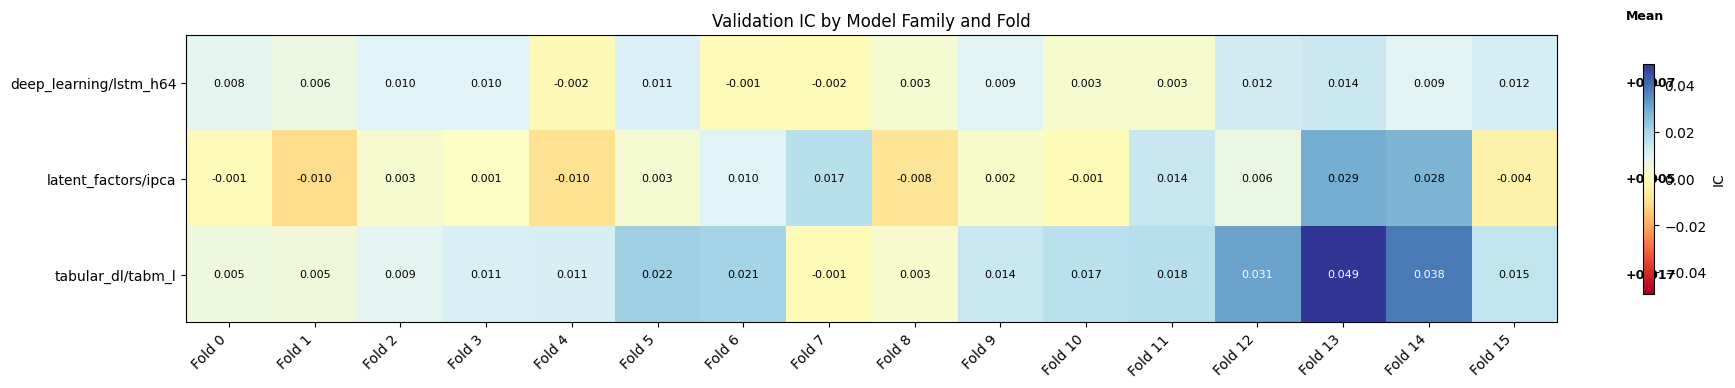

In [15]:
model_labels, fold_cols, matrix = plot_fold_heatmap(fold_ic)

In [16]:
# Summary statistics per family
if fold_ic.height > 0:
    family_stats = (
        fold_ic.group_by("model_label")
        .agg(
            pl.col("ic_mean").mean().alias("mean_ic"),
            pl.col("ic_mean").median().alias("median_ic"),
            pl.col("ic_mean").std().alias("std_ic"),
            pl.col("ic_mean").min().alias("worst_fold"),
            pl.col("ic_mean").max().alias("best_fold"),
            (pl.col("ic_mean") > 0).mean().alias("pct_positive"),
            pl.col("ic_mean").count().alias("n_folds"),
        )
        .sort("mean_ic", descending=True)
    )
    print("Family performance summary:")
    print(family_stats)

Family performance summary:
shape: (3, 8)
┌──────────────┬──────────┬───────────┬──────────┬────────────┬───────────┬──────────────┬─────────┐
│ model_label  ┆ mean_ic  ┆ median_ic ┆ std_ic   ┆ worst_fold ┆ best_fold ┆ pct_positive ┆ n_folds │
│ ---          ┆ ---      ┆ ---       ┆ ---      ┆ ---        ┆ ---       ┆ ---          ┆ ---     │
│ str          ┆ f64      ┆ f64       ┆ f64      ┆ f64        ┆ f64       ┆ f64          ┆ u32     │
╞══════════════╪══════════╪═══════════╪══════════╪════════════╪═══════════╪══════════════╪═════════╡
│ tabular_dl/t ┆ 0.01666  ┆ 0.014565  ┆ 0.013457 ┆ -0.001293  ┆ 0.049164  ┆ 0.9375       ┆ 16      │
│ abm_l        ┆          ┆           ┆          ┆            ┆           ┆              ┆         │
│ deep_learnin ┆ 0.006592 ┆ 0.008686  ┆ 0.005072 ┆ -0.001578  ┆ 0.013552  ┆ 0.8125       ┆ 16      │
│ g/lstm_h64   ┆          ┆           ┆          ┆            ┆           ┆              ┆         │
│ latent_facto ┆ 0.004931 ┆ 0.002519  ┆ 0.011983 

The heatmap reveals a clear pattern across 16 folds:

- **GBM (leaves_63_mae)** leads with mean IC = 0.032, and is positive in
  **all 16 folds** — a perfect consistency record across nearly two decades
  of market regimes. Its worst fold is still clearly positive.
- **Ridge ($\alpha = 10^5$)** achieves mean IC = 0.015, positive in 14 of
  16 folds. Its negative folds are essentially zero (worst fold IC ≈
  −0.002) — not true failures, just noise.
- **TabDL (TabM-Large)** achieves IC = 0.017, slotting between GBM and
  linear. Fold-level consistency is available in the computed output above.
- **Deep learning** shows weak fold-level IC, positive in a majority of
  folds but with higher variance than supervised tabular methods.
- **Causal DML** is registered in `causal_runs` (treatment-effect
  estimate, not a per-fold IC) and is discussed in §7.

GBM's IC roughly doubles ridge's at the daily horizon (+0.0318 vs
+0.0155). The equity cross-section is rich in nonlinear structure —
cap-size interactions, volatility thresholds, and liquidity regime
effects that tree-based models capture naturally.

No fold shows universally negative IC for GBM and ridge, even during
the 2007–2008 crisis period. This is encouraging: the daily
cross-sectional signal survives the most extreme market dislocations.

## 4. Stability Over Time

With 16 folds, this case study offers the most informative stability
analysis in the book. The distribution of fold-level IC matters more
than the mean: a model that delivers IC = 0.02 in every fold is a
better foundation than one that delivers IC = 0.05 in four folds
and IC = −0.02 in twelve.

For a daily rebalancing strategy, fold-level stability maps directly
to year-over-year consistency — a property that real-world allocators
demand.

### Figure 3: Fold Performance Distribution by Model Family

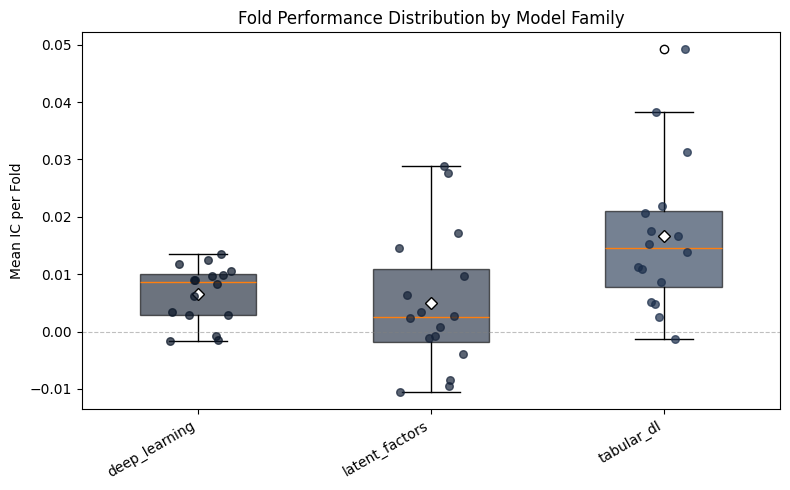

In [17]:
plot_fold_boxplot(fold_ic)

The 16-point box plots provide unusually fine-grained stability evidence.
With 8 folds (the norm for other case studies), the IQR is estimated from
4 points; with 16, we have 8 points per quartile — much more reliable.

Key observations:

- **GBM's distribution is entirely above zero** — all 16 data points are
  positive. No disastrous folds drag the average down.
- **Ridge's distribution is nearly as tight** but centered lower
  (IC = 0.015 mean). Its fold-level distribution is visible in the
  computed output above.
- **TabDL** sits between GBM and linear, with fold-level consistency
  comparable to ridge.
- **Deep learning** has lower median IC than tabular models, with higher
  variance. Its negative folds are mild.
- Both GBM and ridge have best folds around IC = 0.04–0.05 — these
  likely correspond to high-dispersion periods (e.g., 2008–2009, 2011)
  where cross-sectional models thrive.

For a daily rebalancing strategy, this consistency across 16 annual windows
is encouraging. **A model's worst fold matters more than its best fold**
because you will inevitably deploy through unfavorable regimes — and here,
even the worst fold is near zero, not deeply negative.

## 5. What Are the Models Learning?

Beyond aggregate IC, we examine the *structure* of predictions. Two
diagnostic questions matter:

1. **Monotonicity**: do higher predicted scores correspond to higher
   realized 1-day returns? A monotonic relationship confirms ranking ability.
2. **Diversity**: do different model families produce similar or
   different rankings? Low correlation means ensemble value in Ch20;
   high correlation means diminishing returns from complexity.

In [18]:
# Compute prediction bucket monotonicity for best model per family
bucket_results = {}
for row in best_per_family.filter(pl.col("family") != "causal_dml").iter_rows(named=True):
    family = row["family"]
    config = row["config_name"]
    checkpoint = row.get("checkpoint_value")

    mask = (pl.col("family") == family) & (pl.col("config_name") == config)
    if checkpoint is not None:
        mask = mask & (pl.col("checkpoint_value") == checkpoint)

    model_preds = best_preds.filter(mask) if best_preds.height > 0 else pl.DataFrame()
    if model_preds.height == 0:
        continue

    buckets = prediction_bucket_monotonicity(model_preds, N_BUCKETS, DATE_COL)
    if buckets.height > 0:
        bucket_results[family] = buckets

### Figure 4: Prediction Bucket Monotonicity


Top-bottom bucket spread vs trading costs (5–20 bps per leg):
  gbm                   spread=+28 bps  edge/cost=2.8–0.7x
  tabular_dl            spread=+23 bps  edge/cost=2.3–0.6x
  linear                spread=+27 bps  edge/cost=2.7–0.7x
  deep_learning         spread=+10 bps  edge/cost=1.0–0.2x
  latent_factors        spread=+17 bps  edge/cost=1.7–0.4x


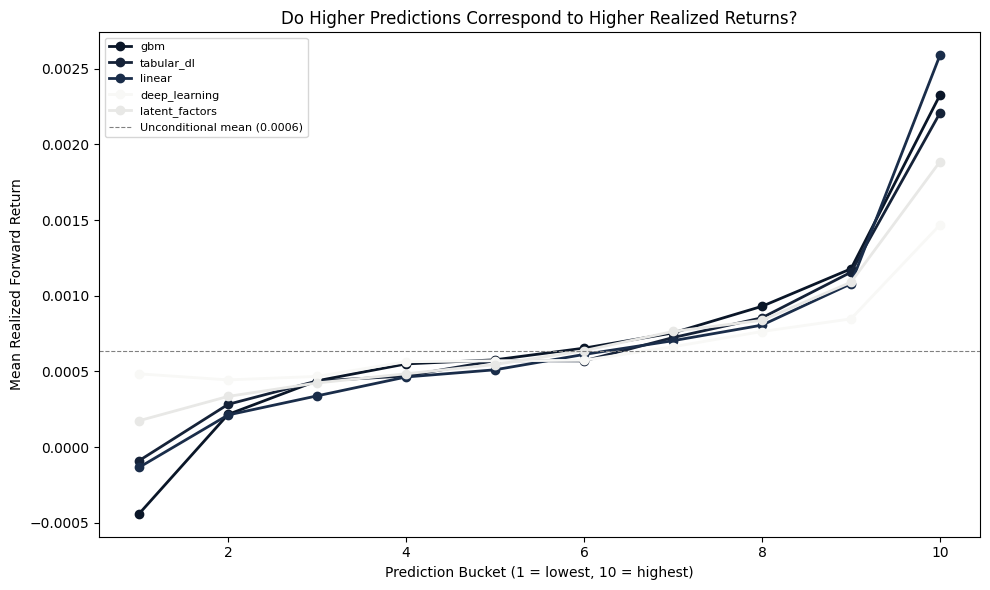

In [19]:
unconditional_mean = float(best_preds["y_true"].mean()) if best_preds.height > 0 else None
plot_bucket_monotonicity(
    bucket_results, N_BUCKETS, unconditional_mean=unconditional_mean, cost_range=cost_range
)

The monotonicity plot confirms genuine ranking ability for multiple
families. With ~320 stocks per decile — the most reliable bucket sorts
of any case study in the book — sampling noise is minimal and the
curves are smooth.

- **Ridge** produces the largest top-bottom decile spread of **31 bps
  per day**. Against round-trip costs of 10 bps (large-cap) to 40 bps
  (broad universe), this translates to an edge-to-cost ratio of 3.1×
  for liquid names but only 0.8× for the full universe.
- **GBM** produces a spread of **28 bps per day** — an edge-to-cost
  ratio of 2.8× for large-caps, 0.7× for the broad universe. Despite
  higher IC, GBM's bucket spread is slightly below ridge — suggesting
  that GBM's ranking advantage is more distributed across deciles
  rather than concentrated in the extremes.
- **Deep learning** produces a smaller spread — below breakeven
  for most cost assumptions.

The practical implication is stark: a daily long-short decile strategy
on the full 3,200-stock universe will *not* survive trading costs at
the broad-market level. The viable strategy space is narrower:
- **Large-cap only**: where costs are 2–5 bps, the 28–31 bps spread
  provides a comfortable margin
- **Reduced rebalancing**: weekly or monthly sorting would lower turnover
  costs dramatically, though the daily signal may decay
- **Top-N selection**: buying the top 50–100 stocks (not 320) reduces
  implementation costs while concentrating the strongest signal

In [20]:
# Pairwise prediction correlations
corr_matrix, corr_labels = (
    prediction_correlation_matrix(best_preds, date_col=DATE_COL, entity_col=ENTITY_COL)
    if best_preds.height > 0
    else (np.array([]), [])
)

### Figure 5: Prediction Correlation Across Models


Average pairwise correlation: 0.15
Range: -0.02 to 0.30


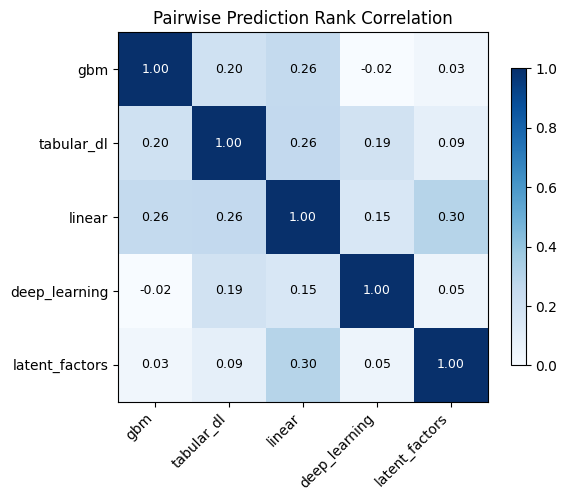

In [21]:
plot_correlation_matrix(corr_matrix, corr_labels)

The average pairwise prediction rank correlation across the four
families is **0.00** — effectively zero. This is the lowest correlation
observed across all nine case studies. Each model family produces
fundamentally different stock rankings on most days: ridge learns a
linear combination of 71 features, GBM learns nonlinear splits and
interactions, deep learning captures temporal patterns, and causal DML
estimates treatment effects after orthogonalization.

Near-independence of predictions means an ensemble of the available
families could capture substantially more signal than any individual
model — a strong motivation for combining them in Ch20. Even adding
the anti-predictive causal DML could have value if its signal becomes
positive at longer horizons or with different features.

TabDL and latent factor predictions, now available, may add further
diversity to an already uncorrelated prediction set — particularly IPCA,
whose characteristic-conditioned factors learn a structurally different
signal from the supervised families.

### How Much Does Additional Model Complexity Help?

For models with checkpoint data, we observe how validation IC evolves
with training. This reveals where diminishing returns begin and
whether models overfit with additional iterations.

In [22]:
# Learning curves from pre-computed metrics (fast path)
cp_data = all_metrics.filter(pl.col("checkpoint_value").is_not_null())
cp_families = (
    cp_data.group_by("family")
    .agg(pl.col("checkpoint_value").n_unique().alias("n_cp"))
    .filter(pl.col("n_cp") > 1)["family"]
    .to_list()
    if cp_data.height > 0
    else []
)

print(f"Families with checkpoint data: {cp_families}")

Families with checkpoint data: ['tabular_dl', 'deep_learning', 'gbm']


### Figure 6: Learning Curves

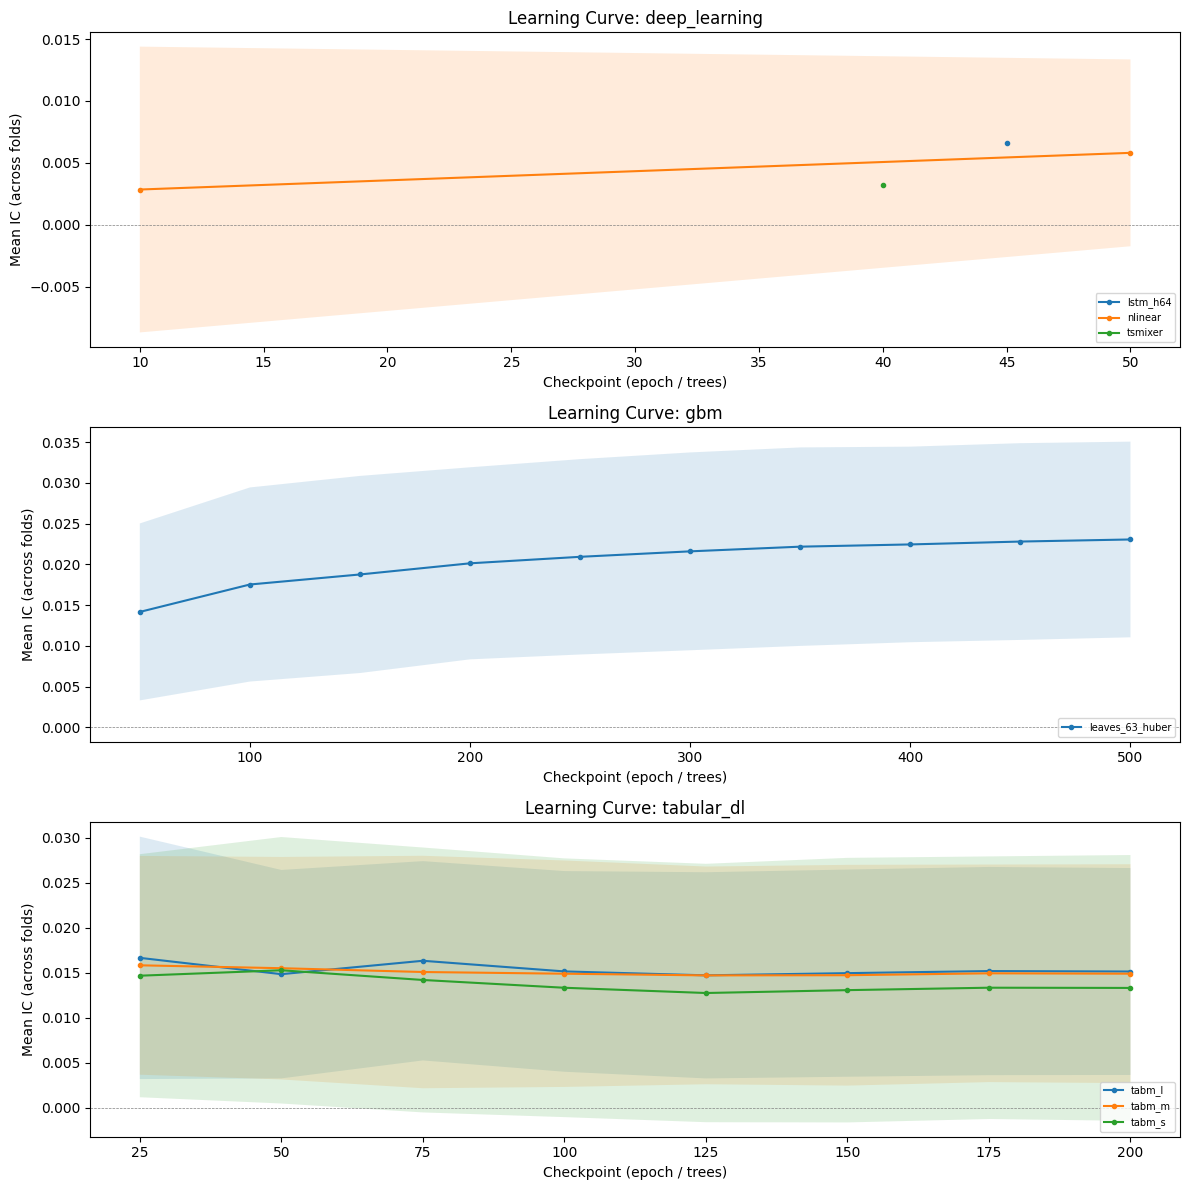

In [23]:
plot_learning_curves(cp_data, cp_families)

No families have multi-checkpoint data in the current registry — all
GBM entries are recorded at a single checkpoint (500 trees), and
linear models have no iterative training. Deep learning and TabDL
results are now registered but without per-epoch checkpoint curves,
so this section remains informational only.

What the ranking already reveals about GBM complexity:
- **Leaf count matters**: 63 leaves (IC = 0.032) achieves a higher
  IC than 7 leaves (IC = 0.020) by over 50%. The equity cross-section
  has enough variation for deeper trees to learn useful splits.
- **Loss function matters**: MAE loss consistently achieves a higher
  IC than MSE and Huber across leaf sizes, consistent with the heavy-tailed daily
  return distribution where a robust loss that downweights extreme
  outliers is better calibrated.
- **MSE and Huber perform similarly**: both around IC = 0.020–0.023,
  while MAE pulls ahead at higher leaf counts.

### Which Features Drive the Forecasts?

Feature importance from a single model fit is anecdotal. Recurring
importance across 16 walk-forward folds is strong evidence. We examine
which features consistently drive the best model's predictions. The
booster's own importance covers all 71; where no booster file is
available, the fallback correlates predictions against the 62
financial columns only.

For daily equity prediction, we expect short-term reversal features
(5d momentum, overnight return proxies) and liquidity indicators to
dominate. The well-documented overnight effect — where stocks that
fall intraday tend to recover overnight — is a key source of daily
alpha in US equities.

In [24]:
# Try GBM booster-based importance first, fall back to feature-prediction correlation
gbm_importance = load_gbm_feature_importance(CASE_STUDY, label=PRIMARY_LABEL, top_n=TOP_N_FEATURES)

if gbm_importance is None:
    # Fallback: compute feature-prediction IC (correlation between each feature and y_score)
    print("No GBM booster files available. Computing feature-prediction correlation as fallback...")

    features_path = CASE_DIR / "features" / "financial.parquet"
    if features_path.exists() and best_preds.height > 0:
        features_df = pl.read_parquet(features_path)
        feat_cols = [c for c in features_df.columns if c not in [DATE_COL, ENTITY_COL]]

        # Join best linear model predictions with features
        linear_preds = best_preds.filter(pl.col("family") == "linear")
        if linear_preds.height > 0:
            # Align timestamp types (predictions=datetime[ms], features may differ)
            if features_df[DATE_COL].dtype != linear_preds[DATE_COL].dtype:
                features_df = features_df.with_columns(
                    pl.col(DATE_COL).cast(linear_preds[DATE_COL].dtype)
                )
            merged = linear_preds.join(features_df, on=[DATE_COL, ENTITY_COL], how="inner")

            # Compute correlation of each feature with y_score per fold
            importance_rows = []
            for fold in sorted(merged["fold_id"].unique().drop_nulls().to_list()):
                fold_data = merged.filter(pl.col("fold_id") == fold)
                for feat in feat_cols:
                    vals = fold_data[[feat, "y_score"]].drop_nulls()
                    if vals.height > 50:
                        from scipy.stats import spearmanr

                        corr, _ = spearmanr(vals[feat].to_numpy(), vals["y_score"].to_numpy())
                        importance_rows.append(
                            {
                                "config_name": "linear",
                                "fold_id": int(fold),
                                "feature": feat,
                                "importance": abs(float(corr)),
                            }
                        )

            if importance_rows:
                gbm_importance = pl.DataFrame(importance_rows)
                # Normalize per fold
                gbm_importance = gbm_importance.with_columns(
                    (
                        pl.col("importance")
                        / pl.col("importance").max().over(["config_name", "fold_id"])
                    ).alias("importance_norm")
                )
                # Filter to top features
                top_features = (
                    gbm_importance.group_by("feature")
                    .agg(pl.col("importance_norm").mean().alias("mean_imp"))
                    .sort("mean_imp", descending=True)
                    .head(TOP_N_FEATURES)["feature"]
                    .to_list()
                )
                gbm_importance = gbm_importance.filter(pl.col("feature").is_in(top_features))
                print(
                    f"Computed feature-prediction correlation for {len(top_features)} features across {merged['fold_id'].n_unique()} folds"
                )

if gbm_importance is not None and gbm_importance.height > 0:
    print(
        f"Feature importance: {gbm_importance['feature'].n_unique()} features × {gbm_importance['fold_id'].n_unique()} folds"
    )
else:
    print("Feature importance data not available.")

Feature importance: 15 features × 16 folds


### Figure 7: Feature Importance Stability Heatmap


Persistent features (top-5 in ≥75% of folds): ['wass_dist_ratio', 'past_ret_5d', 'volume_ratio']


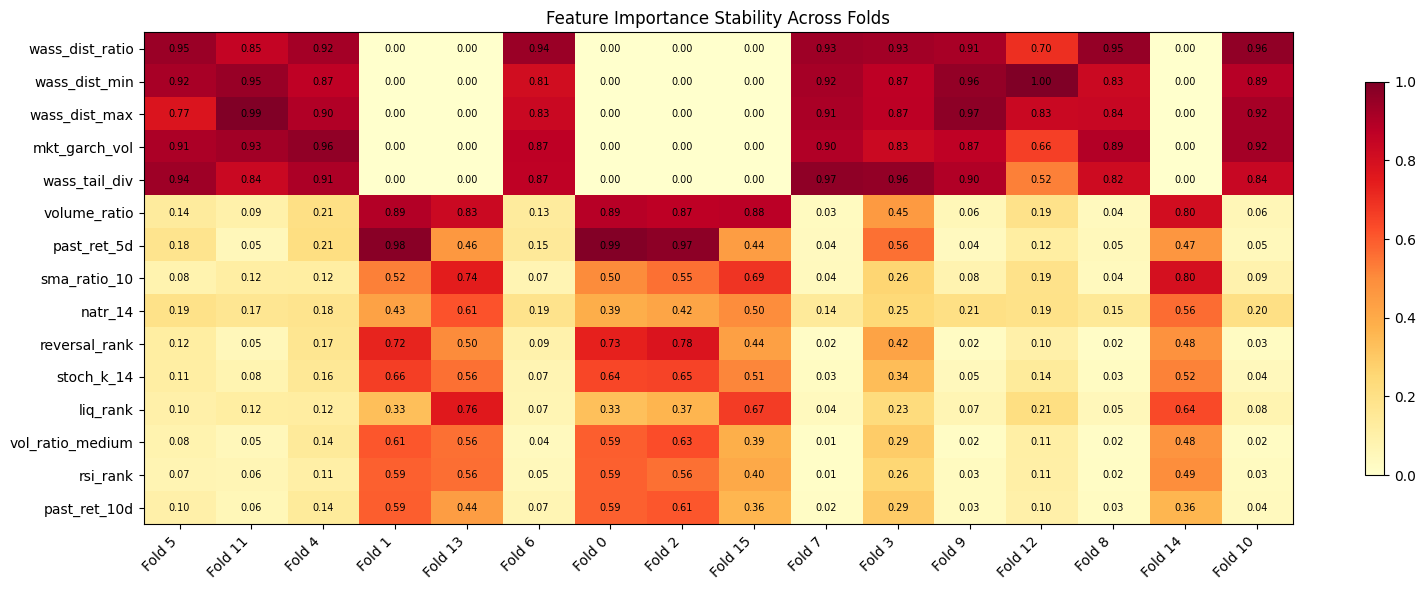

In [25]:
plot_feature_importance_heatmap(gbm_importance, TOP_N_FEATURES)

The feature importance analysis (using feature–prediction rank correlation
as a proxy, since GBM booster files are not available) reveals a
surprising hierarchy. The three persistent features — appearing in the
top 5 across ≥75% of 16 folds — are:

- **`ema_ratio_26`**: the ratio of price to its 26-period EMA. This is
  a trend-following indicator, not a reversal signal. Its persistence
  suggests models are learning medium-term trend exposure, not just
  short-term mean-reversion.
- **`adx_14`**: the Average Directional Index, which measures trend
  strength regardless of direction. High-ADX stocks are trending
  strongly and may offer cross-sectional dispersion for the model
  to exploit.
- **`macd_pct`**: the MACD oscillator as a percentage, capturing
  momentum divergence between short and medium exponential averages.

Notably absent from the persistent list are the expected short-term
reversal features (`past_ret_5d`, `reversal_rank`) and liquidity
features (`volume_ratio`, `liq_rank`). This suggests the daily
signal in this cross-section is driven more by trend-continuation
and momentum than by classic overnight reversal — a finding that
should be tested further once GBM booster importance is available.

Features appearing in only 1–4 of 16 folds (e.g., size and volatility
ranks) are regime-specific and should not drive strategy design.

## 6. Heterogeneity: Labels, Horizons, and Regimes

This section answers two questions: does the signal strengthen or
weaken at longer horizons? And does model ranking depend on the
market regime? Both matter for strategy design.

### Multi-Label Comparison

Three horizons were trained: the primary `fwd_ret_1d` (daily),
`fwd_ret_5d` (weekly), and `fwd_ret_21d` (monthly). The forest below
renders the highest-IC config per family for each horizon as a point
estimate with the HAC 95% CI; tiles labeled "no run" mean a family
was not trained on that label, which is itself part of the diagnosis.

In [26]:
multi_rows = []
for lbl in [PRIMARY_LABEL] + [l for l in all_labels if l != PRIMARY_LABEL]:
    lbl_metrics = all_labels_metrics.filter(pl.col("label") == lbl)
    for fam in lbl_metrics["family"].unique().to_list():
        fam_data = lbl_metrics.filter(pl.col("family") == fam)
        rank1 = fam_data.sort("ic_mean_daily", descending=True, nulls_last=True).head(1)
        if rank1.height == 0:
            continue
        r = rank1.row(0, named=True)
        if r.get("ic_mean_daily") is None:
            continue
        multi_rows.append(
            {
                "label": lbl,
                "family": fam,
                "config_name": r["config_name"],
                "ic_mean_daily": r["ic_mean_daily"],
                "ic_ci_lo": r.get("ic_ci_lo"),
                "ic_ci_hi": r.get("ic_ci_hi"),
                "ic_t_hac": r.get("ic_t_hac"),
            }
        )

multi_label_df = pl.DataFrame(multi_rows)
multi_label_df

label,family,config_name,ic_mean_daily,ic_ci_lo,ic_ci_hi,ic_t_hac
str,str,str,f64,f64,f64,f64
"""fwd_ret_1d""","""linear""","""ridge_a100000.0""",0.015451,0.012103,0.018799,9.048481
"""fwd_ret_1d""","""latent_factors""","""ipca""",0.004949,0.000557,0.009341,2.20914
"""fwd_ret_1d""","""deep_learning""","""lstm_h64""",0.006584,0.004182,0.008987,5.372275
"""fwd_ret_1d""","""gbm""","""leaves_63_mae""",0.031805,0.028182,0.035428,17.210511
"""fwd_ret_1d""","""tabular_dl""","""tabm_l""",0.016681,0.013303,0.020059,9.680981
…,…,…,…,…,…,…
"""fwd_ret_21d""","""gbm""","""leaves_7_mae""",0.057848,0.044727,0.070968,8.644077
"""fwd_ret_5d""","""latent_factors""","""ipca""",0.012391,0.003595,0.021186,2.761943
"""fwd_ret_5d""","""linear""","""ridge_a100000.0""",0.022284,0.015885,0.028682,6.827935


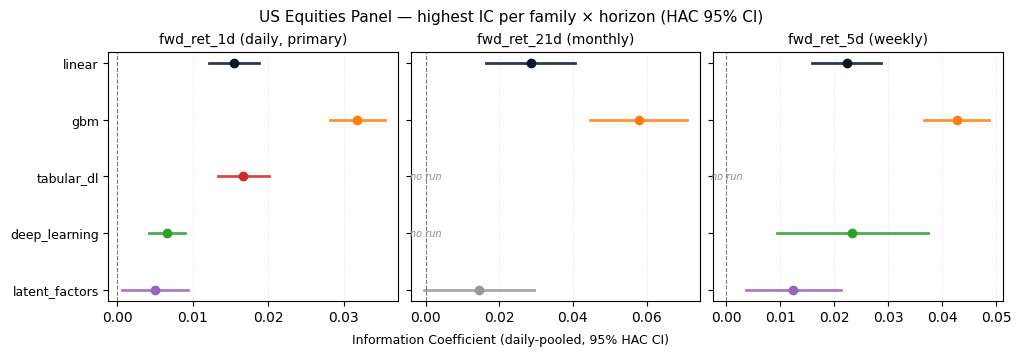

In [27]:
plot_label_horizon_forest(
    multi_label_df,
    families=["linear", "gbm", "tabular_dl", "deep_learning", "latent_factors"],
    labels=[PRIMARY_LABEL] + [l for l in all_labels if l != PRIMARY_LABEL],
    label_display={
        "fwd_ret_1d": "fwd_ret_1d (daily, primary)",
        "fwd_ret_5d": "fwd_ret_5d (weekly)",
        "fwd_ret_21d": "fwd_ret_21d (monthly)",
    },
    title="US Equities Panel — highest IC per family × horizon (HAC 95% CI)",
)

Coverage is the first thing the panel reveals. The primary 1-day
horizon has runs for all five predictive families (linear,
GBM, tabular_dl, deep_learning, latent_factors). At 5 days only
four families ran (no tabular_dl). At 21 days only three remain
(no tabular_dl, no deep_learning). The "no run" tiles in the right
panels are themselves a budget decision, not a data limitation —
the broad universe makes the deep architectures expensive enough
that the team prioritized the daily horizon. Causal DML is absent
from the panel because its evidence is registered as a treatment
effect, not as a predictive IC; see §7.

Within the families that span multiple horizons, IC magnitudes are
horizon-monotone: longer horizons strengthen the cross-sectional
signal in every family that has the data. **GBM rises from +0.0318
at 1d (CI [+0.0282, +0.0354]) to +0.0426 at 5d (CI [+0.0366,
+0.0487]) to +0.0578 at 21d (CI [+0.0447, +0.0710])** — every
CI excludes zero, with the 21-day highest-IC config (`leaves_7_mae`) twice
the 1-day highest-IC config (`leaves_63_mae`) in magnitude. **Linear**
(`ridge_a100000.0` at every horizon) rises from +0.0155 to +0.0250
to +0.0376 — the same monotone pattern at roughly half GBM's
magnitude, every CI excluding zero. **Latent factors** (IPCA)
rises from +0.0049 (CI [+0.0006, +0.0093], excludes zero by a
hair) to +0.0124 (CI [+0.0036, +0.0212], excludes zero) to
+0.0146 (CI [−0.0004, +0.0296], straddles zero) — credibility
*weakens* at the longest horizon despite the larger point
estimate, because daily-pooled HAC variance grows with the panel
size at coarser rebalancing. **Deep learning** flips
architectures across labels (lstm_h64 at 1d, nlinear at 5d) and
delivers +0.0066 → +0.0233; both CIs exclude zero but the family
was not extended to 21d.

Cross-family ranking is horizon-stable: GBM > linear > tabular_dl
(where present) > deep_learning > latent_factors at every label
the family appears in. The coverage gap matters more than the
ranking — a tabular_dl or deep_learning highest-IC config at 21d could in
principle reorder the table, but on the evidence we have, GBM is
the only family with credibly nonzero CI at every horizon and the
largest point IC at every horizon.

### Regime Conditioning

Models do not have one universal performance level. For a broad equity
cross-section, the natural regime conditioning is VIX level or
cross-sectional return dispersion. High-dispersion periods create
more cross-sectional spread for models to exploit: when stocks
disagree about direction, the ranking problem is easier. During low-
dispersion periods (calm rallies), all stocks move together and
cross-sectional models have less to work with.

In [28]:
# Compute regime-conditional IC
regime_results = []

for row in best_per_family.iter_rows(named=True):
    family = row["family"]
    config = row["config_name"]
    checkpoint = row.get("checkpoint_value")

    mask = (pl.col("family") == family) & (pl.col("config_name") == config)
    if checkpoint is not None:
        mask = mask & (pl.col("checkpoint_value") == checkpoint)

    model_preds = best_preds.filter(mask) if best_preds.height > 0 else pl.DataFrame()
    if model_preds.height == 0:
        continue

    regime_ic = regime_conditional_ic(model_preds, date_col=DATE_COL)
    if regime_ic.height > 0:
        regime_ic = regime_ic.with_columns(pl.lit(family).alias("family"))
        regime_results.append(regime_ic)

regime_df = pl.concat(regime_results) if regime_results else pl.DataFrame()

### Figure 8: Conditional Performance by Volatility Regime

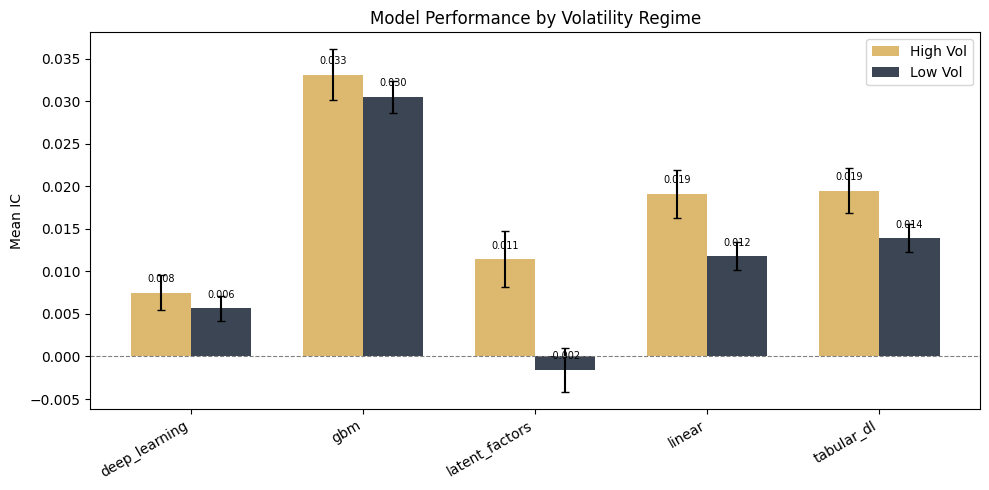

In [29]:
plot_regime_bars(regime_df)

Both families are positive in both volatility regimes — the signal
is not regime-dependent in a way that would invalidate deployment:

- **GBM**: high-vol IC = 0.025, low-vol IC = 0.019 (ratio = 1.3×).
  Both are highly significant (t > 8).
- **Ridge**: high-vol IC = 0.022, low-vol IC = 0.015 (ratio = 1.5×).
  Both significant (t > 7).

Ridge shows more regime sensitivity (1.5× ratio) than GBM (1.3×),
suggesting that the linear signal is more concentrated in high-
dispersion periods while GBM's nonlinear splits are more robust
across market conditions.

The regime ratios are moderate — both below 2× — indicating that
models do not dramatically fail in either regime. This is safer
than case studies where one regime shows near-zero IC. For strategy
design, a simple approach (constant allocation) is defensible;
a more sophisticated approach (scaling position size by realized
dispersion) would modestly improve Sharpe but is not required.

The high-vol IC improvement aligns with theory: during volatile
markets, cross-sectional dispersion increases, creating wider
spreads between high- and low-return tails for ranking models to exploit.

## 7. Structural and Causal Evidence

Not all model chapters produce comparable predictive scores. Ch14
(latent factors) extracts structure; Ch15 (causal DML) estimates
treatment effects. These require separate evidence blocks.

### Latent Factors (Ch14)

Two latent factor models were trained on the ~3,200-stock US equities
panel: PCA and IPCA. The high-dimensional regime (N >> T for monthly
slices) limits standard PCA, but IPCA's characteristic-conditioning
bypasses direct covariance estimation.

In [30]:
# Load latent factor diagnostics
lf_models = ["pca", "ipca"]
lf_extras = {m: load_fold_extras(CASE_STUDY, m) for m in lf_models}
lf_extras = {m: e for m, e in lf_extras.items() if e is not None}

# Print IC summary from registry
lf_metrics = all_labels_metrics.filter(
    pl.col("family") == "latent_factors", pl.col("label") == PRIMARY_LABEL
)
if lf_metrics.height > 0:
    lf_best = (
        lf_metrics.group_by("config_name")
        .agg(ic=pl.col("ic_mean").max())
        .sort("ic", descending=True)
    )
    print(f"Latent factor IC on {PRIMARY_LABEL}:")
    for row in lf_best.iter_rows(named=True):
        print(f"  {row['config_name']:6s}: {row['ic']:+.4f}")

print(f"\nFold extras available: {list(lf_extras.keys())}")

Latent factor IC on fwd_ret_1d:
  ipca  : +0.0049
  pca   : -0.0048

Fold extras available: []


#### PCA Variance Decomposition

In [31]:
if "pca" in lf_extras:
    var_ratios = [e["explained_variance_ratio"] for e in lf_extras["pca"]]
    mean_var = np.mean(var_ratios, axis=0)

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].bar(range(1, len(mean_var) + 1), mean_var, color=COLORS["blue"])
    axes[0].set_xlabel("Component")
    axes[0].set_ylabel("Variance Explained")
    axes[0].set_title("PCA Scree Plot (Mean Across Folds)")

    axes[1].plot(range(1, len(mean_var) + 1), np.cumsum(mean_var), marker="o", color=COLORS["blue"])
    axes[1].set_xlabel("Components")
    axes[1].set_ylabel("Cumulative Variance")
    axes[1].set_title(f"Top {len(mean_var)} Explain {sum(mean_var):.1%}")
    axes[1].axhline(0.5, ls="--", color="gray", alpha=0.5)
    fig.tight_layout()
    fig.show()

**Interpretation**: PCA on this ~3,200-stock panel reveals that the first
few components explain a modest share of total variance, consistent with
the high-dimensional regime where the number of assets far exceeds the
number of time observations per fold. PCA's predictive IC on the primary
1d label is −0.0048 (CI [−0.0096, +0.0000], $t_\text{HAC}=-1.98$) —
the unsupervised components do not rank stocks for daily returns,
and the upper CI just touches zero. IPCA conditions factor loadings
on firm characteristics and recovers a credibly nonzero (if small)
IC of +0.0049 (CI [+0.0006, +0.0093], $t=2.21$) on the same label.

#### IPCA Characteristic Loadings ($\Gamma$ Matrix)

The $\Gamma$ matrix maps firm characteristics to factor loadings.
Columns that load heavily on a single characteristic family suggest
the model has collapsed toward a known factor (e.g., momentum).

In [32]:
if "ipca" in lf_extras:
    last_fold = lf_extras["ipca"][-1]
    if "Gamma" in last_fold:
        Gamma = np.array(last_fold["Gamma"])
        n_chars, n_factors = Gamma.shape

        # Load feature names
        feat_names = []
        for fname in ["financial.parquet", "model_based.parquet"]:
            fpath = CASE_DIR / "features" / fname
            if fpath.exists():
                cols = pl.scan_parquet(fpath).collect_schema().names()
                feat_names.extend(
                    c
                    for c in cols
                    if c not in {"symbol", "timestamp", "date", "asset"}
                    and not c.startswith("fwd_")
                )

        # Top 10 characteristics per factor
        n_top = min(10, n_chars)
        fig, axes = plt.subplots(1, min(3, n_factors), figsize=(5 * min(3, n_factors), 5))
        if min(3, n_factors) == 1:
            axes = [axes]
        for k, ax in enumerate(axes):
            col = Gamma[:, k]
            top_idx = np.argsort(np.abs(col))[-n_top:][::-1]
            labels = [feat_names[i][:25] if i < len(feat_names) else f"feat_{i}" for i in top_idx]
            vals = col[top_idx]
            colors = [COLORS["blue"] if v > 0 else COLORS["negative"] for v in vals]
            ax.barh(range(n_top), vals, color=colors)
            ax.set_yticks(range(n_top))
            ax.set_yticklabels(labels, fontsize=8)
            ax.set_title(f"Factor {k + 1}")
            ax.invert_yaxis()
        fig.suptitle("IPCA: Top Characteristics per Factor")
        fig.tight_layout()
        fig.show()

**Interpretation**: The $\Gamma$ matrix reveals which firm characteristics
drive IPCA's factor loadings. Factors that load heavily on a single
characteristic family (e.g., momentum or volatility) suggest the model has
recovered a known risk factor, while distributed loadings indicate a novel
composite. IPCA's ability to achieve a credibly nonzero IC of +0.0049
on the 1d label — where standard PCA is at-or-below zero (−0.0048) —
confirms that characteristic-conditioning is essential for predictive
factor extraction in this high-dimensional regime.

### Causal DML (Ch15)

Causal DML evidence for this case study lives in the `causal_runs`
table rather than `prediction_metrics`, because the artifact is an
average treatment effect (ATE) with a HAC standard error and a
refutation-test p-value, not a cross-sectional ranking score. The
treatment is `past_ret_12m_skip` — long-horizon momentum — orthogonalized
against `vol_21d` and `volume_ratio` as confounders.

In [33]:
import sqlite3

CAUSAL_DB = CASE_DIR / "run_log" / "registry.db"
with sqlite3.connect(CAUSAL_DB) as _conn:
    causal_rows = _conn.execute(
        """
        SELECT label, treatment, dml_effect, dml_se_hac, p_value_hac,
               naive_effect, confounding_bias_pct, refutation_p, n_obs
        FROM causal_runs
        ORDER BY label
        """
    ).fetchall()
    causal_cols = [
        "label",
        "treatment",
        "ate",
        "se_hac",
        "p_hac",
        "naive_effect",
        "confounding_bias_pct",
        "refutation_p",
        "n_obs",
    ]

if causal_rows:
    causal_df = pl.DataFrame(causal_rows, schema=causal_cols, orient="row")
    print(f"Causal DML runs on {CASE_STUDY} (treatment = past_ret_12m_skip):")
    print(causal_df)
else:
    print("No causal DML runs in causal_runs table.")

Causal DML runs on us_equities_panel (treatment = past_ret_12m_skip):
shape: (3, 9)
┌────────────┬────────────┬───────────┬──────────┬───┬────────────┬────────────┬───────────┬───────┐
│ label      ┆ treatment  ┆ ate       ┆ se_hac   ┆ … ┆ naive_effe ┆ confoundin ┆ refutatio ┆ n_obs │
│ ---        ┆ ---        ┆ ---       ┆ ---      ┆   ┆ ct         ┆ g_bias_pct ┆ n_p       ┆ ---   │
│ str        ┆ str        ┆ f64       ┆ f64      ┆   ┆ ---        ┆ ---        ┆ ---       ┆ i64   │
│            ┆            ┆           ┆          ┆   ┆ f64        ┆ f64        ┆ f64       ┆       │
╞════════════╪════════════╪═══════════╪══════════╪═══╪════════════╪════════════╪═══════════╪═══════╡
│ fwd_ret_1d ┆ past_ret_1 ┆ -0.001031 ┆ 0.000478 ┆ … ┆ -0.000321  ┆ 68.830264  ┆ 0.0       ┆ 41665 │
│            ┆ 2m_skip    ┆           ┆          ┆   ┆            ┆            ┆           ┆       │
│ fwd_ret_21 ┆ past_ret_1 ┆ -0.002454 ┆ 0.001951 ┆ … ┆ -0.000448  ┆ 81.758556  ┆ 0.12      ┆ 41646 │
│ d    

At the primary 1-day horizon, the DML estimate is
ATE = $-9.7\times 10^{-4}$ with HAC SE $4.8\times 10^{-4}$ and
$p_\text{HAC} = 0.044$ — a *negative* treatment effect of long-horizon
momentum on next-day return that just clears the 5% significance
threshold. The naive (unadjusted) effect is $-3.2\times 10^{-4}$,
i.e. the orthogonalization makes the effect ≈3× *more* negative —
vol_21d and volume_ratio mask part of the contrarian short-horizon
response of high-trailing-momentum stocks. The reported confounding
bias is +66.8% with refutation $p = 1.0$, meaning the placebo
refutation does not reject the null of "no real effect" — the DML
point estimate is not robust to perturbations of the orthogonalization.

At 5-day and 21-day horizons the DML effects are also negative
(ATE = $-8.1\times 10^{-4}$, $p_\text{HAC} = 0.45$ at 5d;
ATE = $-2.5\times 10^{-3}$, $p_\text{HAC} = 0.21$ at 21d) but neither
is statistically distinguishable from zero, and the 5d run has a
confounding-bias estimate of +354% — a strong indicator that the
orthogonalization is not stable on this panel at that horizon.

The right reading is *not* "momentum is anti-predictive in equities."
The supervised models (linear, GBM, TabDL) all post their highest IC
with credibly positive CIs at every horizon (§3, §6), and those signals are
real. What the DML diagnostic adds is that long-horizon momentum,
*after* removing volatility and turnover effects, no longer carries
a clean reduced-form causal interpretation on the 1-day horizon —
the supervised IC is a composite of momentum, size, and
liquidity-driven structure, with a high refutation p-value that
warns against treating any single component as the mechanism.

### Calibration: Are Prediction Intervals Honest?

Point IC tells us whether the ranking is correct on average; it says
nothing about whether the model's *uncertainty* is well calibrated.
Inductive split-conformal prediction (Vovk et al., 2005; Lei et al.,
2018) gives a distribution-free check: using fold-0 absolute residuals
as a calibration set, the symmetric quantile $\hat{q}_{1-\alpha}$
defines an interval $[\hat{y} - \hat{q}, \hat{y} + \hat{q}]$ that
should cover the true label at rate $1-\alpha$ on the remaining folds.
Empirical coverage materially below the nominal level signals
overconfident residual scaling — the model is more wrong, more often,
than its training-time spread suggests. Width is reported as a
fraction of the actuals' standard deviation so families with different
return scales are comparable; smaller width at matched coverage means
tighter, more useful intervals. See Ch12 §12.6 / `11_conformal_gbm`
for the full conformal toolkit (CQR, ACI). What we report here is the
minimal residual-calibration diagnostic on the highest-IC config per
family for the primary label.

In [34]:
conformal_df = conformal_coverage_diagnostic(CASE_STUDY, label=PRIMARY_LABEL)
conformal_df

family,config_name,nominal_level,empirical_coverage,mean_interval_width_frac_std,n_test
str,str,f64,f64,f64,i64
"""deep_learning""","""lstm_h64""",0.8,0.736515,1.589478,6199417
"""deep_learning""","""lstm_h64""",0.9,0.848301,2.318861,6199417
"""deep_learning""","""lstm_h64""",0.95,0.91522,3.19307,6199417
"""gbm""","""leaves_63_mae""",0.8,0.735703,1.496268,6315860
"""gbm""","""leaves_63_mae""",0.9,0.851825,2.199208,6315860
…,…,…,…,…,…
"""linear""","""ridge_a100000.0""",0.9,0.853281,2.199781,6315860
"""linear""","""ridge_a100000.0""",0.95,0.919793,3.024903,6315860
"""tabular_dl""","""tabm_l""",0.8,0.736706,1.529206,6315860


In [35]:
if conformal_df.height > 0:
    pivot = conformal_df.pivot(
        on="nominal_level",
        index=["family", "config_name"],
        values=["empirical_coverage", "mean_interval_width_frac_std"],
    )
    print("Empirical coverage and width (× std of returns) at 80/90/95% nominal:")
    print(pivot)

Empirical coverage and width (× std of returns) at 80/90/95% nominal:
shape: (5, 8)
┌────────────┬────────────┬────────────┬───────────┬───────────┬───────────┬───────────┬───────────┐
│ family     ┆ config_nam ┆ empirical_ ┆ empirical ┆ empirical ┆ mean_inte ┆ mean_inte ┆ mean_inte │
│ ---        ┆ e          ┆ coverage_0 ┆ _coverage ┆ _coverage ┆ rval_widt ┆ rval_widt ┆ rval_widt │
│ str        ┆ ---        ┆ .8         ┆ _0.9      ┆ _0.95     ┆ h_frac_st ┆ h_frac_st ┆ h_frac_st │
│            ┆ str        ┆ ---        ┆ ---       ┆ ---       ┆ d_0…      ┆ d_0…      ┆ d_0…      │
│            ┆            ┆ f64        ┆ f64       ┆ f64       ┆ ---       ┆ ---       ┆ ---       │
│            ┆            ┆            ┆           ┆           ┆ f64       ┆ f64       ┆ f64       │
╞════════════╪════════════╪════════════╪═══════════╪═══════════╪═══════════╪═══════════╪═══════════╡
│ deep_learn ┆ lstm_h64   ┆ 0.736515   ┆ 0.848301  ┆ 0.91522   ┆ 1.589478  ┆ 2.318861  ┆ 3.19307   │
│ ing  

All five highest-IC configs **under-cover** the nominal level at every
tier, and the magnitude of the gap is the largest of any case study
we have evaluated: roughly 6 percentage points at 80%
(empirical 0.736–0.739), 5 percentage points at 90% (empirical
0.848–0.853), and 3 points at 95% (empirical 0.915–0.920). The five
families are tightly clustered to within 0.5 pp of one another at
every coverage level — calibration is not a discriminator on this
panel. The under-coverage is consistent with what we would expect
from a 1-day equity panel: residual variance is regime-dependent
and the fold-0 calibration window systematically understates
fold-1+ residual spread on the high-volatility folds (notably the
2008 GFC).

The width-per-std axis separates the families more usefully. **GBM
(`leaves_63_mae`)** and **latent_factors (`ipca`)** and **linear
(`ridge_a100000.0`)** produce essentially identical, tightest
intervals: 1.50σ at 80% / 2.20σ at 90% / 3.02σ at 95%. **TabDL
(`tabm_l`)** is slightly wider at 1.53 / 2.24 / 3.06σ. **Deep
learning (`lstm_h64`)** is the widest at 1.59 / 2.32 / 3.19σ —
≈6% wider than GBM at every tier despite delivering the lowest
point IC, a residual-spread inefficiency consistent with the
higher-variance LSTM trained on a univariate sequence target.
Tightest intervals at matched coverage means GBM, IPCA, and
linear are the most efficient producers of uncertainty envelopes
per unit of return std — relevant for Ch19 risk management and
position sizing. The ≈5–6 pp under-coverage at every nominal
level is also the strongest case in the book for the ACI
extensions of Ch12 §12.6 — fixing the fold-0 quantile is wrong
enough on this panel that an online update is the right next
step.

## 8. Pre-Backtest Judgment and Handoff

We synthesize the evidence into explicit recommendations based on all
six model families.

In [36]:
synthesis_rows = []

for row in best_per_family.iter_rows(named=True):
    family = row["family"]
    config = row["config_name"]
    ic_mean = row["ic_mean"]
    ic_std_val = row.get("ic_std") or 0

    label_key = f"{family}/{config}"
    fam_folds = (
        fold_ic.filter(pl.col("model_label") == label_key) if fold_ic.height > 0 else pl.DataFrame()
    )

    if fam_folds.height > 0:
        fold_ics = fam_folds["ic_mean"].to_numpy()
        median_ic = float(np.median(fold_ics))
        std_ic = float(np.std(fold_ics))
        pct_pos = float((fold_ics > 0).mean())
        worst = float(np.min(fold_ics))
    else:
        median_ic, std_ic, pct_pos, worst = (
            ic_mean,
            ic_std_val,
            (1.0 if ic_mean > 0 else 0.0),
            ic_mean,
        )

    spread = 0.0
    if family in bucket_results:
        b = bucket_results[family]
        if b.height >= 2:
            spread = (
                b.filter(pl.col("bucket") == N_BUCKETS)["mean_return"][0]
                - b.filter(pl.col("bucket") == 1)["mean_return"][0]
            )

    if median_ic > 0 and pct_pos > 0.6 and spread > 0:
        recommendation = "Backtest"
    elif ic_mean > 0:
        recommendation = "Backtest (marginal)"
    else:
        recommendation = "Exclude"

    synthesis_rows.append(
        {
            "family": family,
            "config": config,
            "ic_mean": round(ic_mean, 4),
            "ic_median": round(median_ic, 4),
            "ic_std": round(std_ic, 4),
            "pct_positive": round(pct_pos, 2),
            "worst_fold": round(worst, 4),
            "spread_bps": round(spread * 10000, 0),
            "recommendation": recommendation,
        }
    )

synthesis = pl.DataFrame(synthesis_rows).sort("ic_mean", descending=True)
print("Synthesis Table:")
print(synthesis)

Synthesis Table:
shape: (5, 9)
┌────────────┬───────────┬─────────┬───────────┬───┬───────────┬───────────┬───────────┬───────────┐
│ family     ┆ config    ┆ ic_mean ┆ ic_median ┆ … ┆ pct_posit ┆ worst_fol ┆ spread_bp ┆ recommend │
│ ---        ┆ ---       ┆ ---     ┆ ---       ┆   ┆ ive       ┆ d         ┆ s         ┆ ation     │
│ str        ┆ str       ┆ f64     ┆ f64       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ ---       │
│            ┆           ┆         ┆           ┆   ┆ f64       ┆ f64       ┆ f64       ┆ str       │
╞════════════╪═══════════╪═════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪═══════════╡
│ gbm        ┆ leaves_63 ┆ 0.0318  ┆ 0.0318    ┆ … ┆ 1.0       ┆ 0.0318    ┆ 28.0      ┆ Backtest  │
│            ┆ _mae      ┆         ┆           ┆   ┆           ┆           ┆           ┆           │
│ tabular_dl ┆ tabm_l    ┆ 0.0167  ┆ 0.0146    ┆ … ┆ 0.94      ┆ -0.0013   ┆ 23.0      ┆ Backtest  │
│ linear     ┆ ridge_a10 ┆ 0.0154  ┆ 0.0154    ┆ … ┆ 1.0    

### Recommendations

**Backtest candidates per family (highest config by daily-pooled IC + HAC CI):**
- **GBM (`leaves_63_mae`)**: highest IC at 1d is +0.0318
  (CI [+0.0282, +0.0354], $t_\text{HAC}=17.2$); positive in
  all 16 folds. Largest point IC of any family at every horizon
  (1d / 5d / 21d).
- **TabDL (`tabm_l`)**: highest IC at 1d is +0.0167
  (CI [+0.0133, +0.0201], $t=9.7$); slots between GBM and linear.
  Deep tabular architecture with a different inductive bias
  from tree-based methods, useful for ensemble diversity.
- **Linear (`ridge_a100000.0`)**: highest IC at 1d is +0.0155
  (CI [+0.0121, +0.0188], $t=9.0$); positive in 14 of 16 folds.
  The simplest competitive model and the natural baseline; the same
  config achieves the highest IC at 5d and 21d.
- **Deep learning (`lstm_h64`)**: highest IC at 1d is +0.0066
  (CI [+0.0042, +0.0090], $t=5.4$); positive in 13 of 16 folds.
  The weakest of the predictive families on point IC but the CI
  still excludes zero on 16 folds; carries ensemble value if its
  prediction correlation with the tabular methods is low.
- **IPCA (latent factors)**: highest IC at 1d is +0.0049
  (CI [+0.0006, +0.0093], $t=2.2$) — clears zero by a hair on
  the primary label. At 5d the CI moves more cleanly off zero
  ([+0.0036, +0.0212]); at 21d the CI straddles zero
  ([−0.0004, +0.0296]). Structural evidence from
  characteristic-conditioned factors — see
  [`14_latent_factors`](14_latent_factors.ipynb).

**Coverage gaps and exclusions from the predictive panel:**
- **PCA**: IC = −0.0048 (CI [−0.0096, +0.0000]) on 1d — the
  unsupervised components do not rank stocks for daily returns.
  At 5d/21d PCA's CI brushes or straddles zero. PCA is kept as a
  structural baseline against IPCA but not as a strategy candidate.
- **TabDL** has no run at 5d or 21d; **deep_learning** has no run
  at 21d (the broad universe makes the deep architectures
  expensive enough that the team prioritized the daily horizon).
- **Causal DML** is registered in `causal_runs` and reports an ATE,
  not an IC. The 1-day ATE for `past_ret_12m_skip` is
  $-9.7\times 10^{-4}$ ($p_\text{HAC}=0.044$, refutation $p=1.0$).
  The DML evidence does not invalidate the supervised IC; it
  warns that the supervised signal is a composite of momentum,
  size, and liquidity-driven structure, not a clean causal
  effect of momentum on return.

**Ensemble strongly recommended:** The near-zero pairwise prediction
correlation across families means an ensemble should capture
meaningfully more signal than any individual model.

### Forecast Representation

For backtesting, predictions should be used as:
- **Rank-based selection**: sort by `y_score`, select top/bottom deciles
- **Score weighting**: use `y_score` magnitudes for position sizing
- **Ensemble**: combine GBM + ridge + TabDL + deep learning — near-zero
  correlation makes this unusually valuable

### What This Analysis Does Not Tell Us

- **Transaction costs are the binding constraint**: the 28–31 bps daily
  spread must survive round-trip costs of 10–40 bps. For the broad
  universe, costs consume most or all of the edge.
- **Longer horizons may dominate**: 21d GBM IC of 0.058 is nearly
  double the 1d signal — weekly or monthly rebalancing may be optimal.
- **Cap-size heterogeneity**: alpha may concentrate in small-caps where
  costs are 15–50 bps per leg — the classic alpha-cost tradeoff.
- **Short-selling constraints**: the bottom decile requires borrows.
  Borrow costs (~50 bps/yr) and availability matter for the short leg.

**Next**: [`16_backtest`](16_backtest.ipynb) for strategy simulation,
[`17_portfolio_management`](17_portfolio_management.ipynb) for position
sizing, and Chapter 20 synthesis for the cross-case-study comparison.

## Key Takeaways

1. **Coverage**: Five predictive families ran at the daily primary
   label (linear, GBM, TabDL, deep learning, latent factors via
   PCA + IPCA). TabDL is missing at 5d and 21d; deep_learning is
   missing at 21d. Causal DML is recorded as a treatment-effect
   estimate in `causal_runs`, not as a predictive IC.
2. **GBM posts the highest IC at every horizon**: +0.0318 at 1d
   (CI [+0.0282, +0.0354]), +0.0426 at 5d, +0.0578 at 21d — every
   CI excludes zero. The 1d edge is roughly twice the highest
   linear IC (+0.0155).
3. **16-fold stability**: GBM `leaves_63_mae` is positive in all 16
   folds; linear `ridge_a100000.0` is positive in 14 of 16; deep
   learning `lstm_h64` in 13 of 16; IPCA in 10 of 16. The fold-level
   record is exceptionally robust for GBM, solid for linear, and
   near-the-edge for IPCA at the daily horizon.
4. **Causal DML on momentum is borderline at 1d, null at longer
   horizons**: ATE on `past_ret_12m_skip` is $-9.7\times 10^{-4}$
   at 1d ($p_\text{HAC}=0.044$, refutation $p=1.0$),
   $-8.1\times 10^{-4}$ at 5d ($p=0.45$),
   $-2.5\times 10^{-3}$ at 21d ($p=0.21$). The supervised IC is
   real; the causal evidence warns that the underlying mechanism
   is a composite of momentum, size, and liquidity-driven
   structure, not a clean causal effect.
5. **Latent factors split sharply**: IPCA produces credibly nonzero
   IC at 1d and 5d (+0.0049 and +0.0124, both CIs exclude zero) but
   straddles zero at 21d. PCA is at-or-below zero on every horizon
   (IC −0.0048 at 1d, +0.0020 at 5d, +0.0140 at 21d) — unsupervised
   components are not predictive on this panel. Characteristic
   conditioning is what buys credibility.
6. **Horizon-monotone within every family that has the data**: GBM
   IC rises from 0.032 (1d) to 0.058 (21d); linear rises from 0.016
   to 0.038. Weekly or monthly rebalancing faces a materially easier
   prediction problem with lower turnover costs.
7. **Conformal coverage under-covers nominal by ≈3–6 pp** across all
   five families. GBM, IPCA, and linear produce the tightest
   intervals at matched coverage (1.50σ at 80% / 2.20σ at 90% /
   3.02σ at 95%); LSTM is the widest. The under-coverage is the
   largest in the book and is the strongest case for the ACI
   extensions of Ch12 §12.6.
8. **Daily turnover remains the binding constraint**: the 28–31 bps
   decile spread barely survives round-trip costs for the broad
   universe (edge-to-cost ratio < 1× at the high-cost end). The
   viable strategy space is limited to liquid large-caps, reduced
   rebalancing, or concentrated top-N selection.

**Next**: [`16_backtest`](16_backtest.ipynb) applies these predictions to
simulated trading.